# VAYU — Rooftop Solar Analysis Pipeline
**AI for Bharat Hackathon, PAN IIT 2026**

### Run order
1. **Cell 1** — environment & GPU setup
2. **Cell 2** — install packages → *Kernel → Restart Kernel*
3. **Cell 3** — imports & paths
4. **Cell 4** — train/val split (skipped if already done)
5. **Cell 5** — visualise sample annotations
6. **Cell 6** — auto-annotate unlabeled images
7. **Cell 7** — merge auto-annotated into training set
8. **Cell 8** — train YOLOv12m-seg
9. **Cell 9** — plot training metrics
10. **Cell 10** — solar calculation engine
11. **Cell 11** — save all annotations to JSON
12. **Cell 12** — multi-agent Groq debate functions
13. **Cell 13** — full inference pipeline
14. **Cell 14** — batch inference on validation set
15. **Cell 15** — analyse your own image
16. **Cell 16** — model evaluation
17. **Cell 17** — summary dashboard

In [1]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\vedan\AppData\Local\Programs\Python\Python312\python.exe
3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]


In [2]:
# ── Cell 1: Environment Detection & GPU Setup ────────────────────────────
import sys, os, subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def _gpu_info():
    try:
        r = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=10)
        return r.stdout.strip() if r.returncode == 0 else None
    except Exception:
        return None

gpu = _gpu_info()

# ── Force GPU device globally ────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    DEVICE = 0   # Use first CUDA GPU
    torch.cuda.set_device(DEVICE)
    _gpu_name = torch.cuda.get_device_name(DEVICE)
    _gpu_mem  = torch.cuda.get_device_properties(DEVICE).total_memory // 1024**3
    print(f'✓ CUDA GPU detected: {_gpu_name} ({_gpu_mem} GB)')
    print(f'  All training/inference will use GPU (device={DEVICE})')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
    print('Apple MPS GPU available.')
else:
    DEVICE = 'cpu'
    print('⚠ No GPU — training will use CPU (slow).')

if IN_COLAB:
    from google.colab import drive
    print('Mounting Google Drive...')
    drive.mount('/content/drive')
    BASE_DIR_STR = '/content/drive/MyDrive/AI_for_Bharat'
    os.makedirs(BASE_DIR_STR, exist_ok=True)
    COLAB_BATCH = 16
    try:
        from google.colab import userdata
        _k = userdata.get('GROQ_API_KEY')
        if _k:
            os.environ['GROQ_API_KEY'] = _k
            print('GROQ_API_KEY loaded from Colab Secrets.')
    except Exception:
        pass
    print(f'Drive base : {BASE_DIR_STR}')
    print(f'Ensure these folders exist on Drive:')
    print(f'  {BASE_DIR_STR}/dataset/train/images/')
    print(f'  {BASE_DIR_STR}/all/')
else:
    BASE_DIR_STR = r'C:/Users/vedan/OneDrive/Pictures/Documents/AI FOR BHARAT'
    COLAB_BATCH  = 8

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local Jupyter'}")
print(f'Base dir    : {BASE_DIR_STR}')
print(f'Device      : {DEVICE}')


✓ CUDA GPU detected: NVIDIA GeForce RTX 2050 (3 GB)
  All training/inference will use GPU (device=0)
Environment : Local Jupyter
Base dir    : C:/Users/vedan/OneDrive/Pictures/Documents/AI FOR BHARAT
Device      : 0


In [3]:
# ── Cell 2: Install Packages — restart kernel after this cell ─────────────
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", *args, "-q"])

# ultralytics>=8.3.50 is required for YOLOv12 support
pip("install", "ultralytics>=8.3.50")
pip("uninstall", "groq", "-y")
pip("install", "httpx==0.27.0", "groq==0.9.0")

for pkg in ["shapely", "python-dotenv", "tqdm"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg}...")
        pip("install", pkg)

# Verify ultralytics version
import ultralytics
print(f"ultralytics version: {ultralytics.__version__}")
print("All packages installed.")
print("NEXT: Kernel -> Restart Kernel, then run Cell 1 again, then Cell 3 onwards.")


Installing python-dotenv...
ultralytics version: 8.4.46
All packages installed.
NEXT: Kernel -> Restart Kernel, then run Cell 1 again, then Cell 3 onwards.


In [4]:
# ── Cell 2b: Download YOLOv12 weights ────────────────────────────────────
from pathlib import Path
import urllib.request, shutil

_MODEL_FILE = 'yolo26m-seg.pt'   # intentionally NOT named MODEL_NAME
print(f'Model file  : {repr(_MODEL_FILE)}')

if Path(_MODEL_FILE).exists():
    size_mb = Path(_MODEL_FILE).stat().st_size // 1024**2
    print(f'Already downloaded ({size_mb} MB) — skipping.')
else:
    print('Downloading yolo26m-seg.pt ...')
    _downloaded = False

    # Method 1: ultralytics auto-download (needs ultralytics>=8.3.50)
    try:
        from ultralytics.utils.downloads import safe_download
        safe_download(f'https://github.com/ultralytics/assets/releases/latest/download/{_MODEL_FILE}',
                      file=_MODEL_FILE)
        _downloaded = Path(_MODEL_FILE).exists()
        if _downloaded:
            print('Downloaded via ultralytics safe_download.')
    except Exception as _e1:
        print(f'ultralytics method failed: {_e1}')

    # Method 2: direct urllib download
    if not _downloaded:
        _url = f'https://github.com/ultralytics/assets/releases/latest/download/{_MODEL_FILE}'
        print(f'Direct download from: {_url}')
        try:
            with urllib.request.urlopen(_url, timeout=120) as _r, open(_MODEL_FILE, 'wb') as _f:
                shutil.copyfileobj(_r, _f)
            _downloaded = Path(_MODEL_FILE).exists()
            if _downloaded:
                print('Downloaded via direct URL.')
        except Exception as _e2:
            print(f'Direct download failed: {_e2}')

    if not _downloaded:
        print('ERROR: Both download methods failed.')
        print('Manual fix: download yolo26m-seg.pt from')
        print('  https://github.com/ultralytics/assets/releases')
        print('  and place it in:', Path('.').resolve())
    else:
        size_mb = Path(_MODEL_FILE).stat().st_size // 1024**2
        print(f'SUCCESS: {_MODEL_FILE} ready ({size_mb} MB)')


Model file  : 'yolo26m-seg.pt'
Already downloaded (52 MB) — skipping.


In [5]:
# ── Cell 3: Imports & Paths ──────────────────────────────────────────────
import os, json, shutil, random, math
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Polygon
from tqdm.notebook import tqdm
from dotenv import load_dotenv
from groq import Groq
from ultralytics import YOLO

load_dotenv()
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
assert GROQ_API_KEY, 'GROQ_API_KEY missing — add to .env or Colab Secrets'
groq_client = Groq(api_key=GROQ_API_KEY)

# ── Paths ─────────────────────────────────────────────────────────────────
# BASE_DIR_STR is set in Cell 1 — always run Cell 1 first
BASE_DIR           = Path(BASE_DIR_STR)
TRAIN_IMG          = BASE_DIR / 'dataset' / 'train' / 'images'
TRAIN_LBL          = BASE_DIR / 'dataset' / 'train' / 'labels'
UNLABELED          = BASE_DIR / 'all'
SPLIT_DIR          = BASE_DIR / 'dataset'
RUNS_DIR           = BASE_DIR / 'runs'
AUTO_LBL_DIR       = BASE_DIR / 'all_labels'
ANNOTATIONS_DIR    = BASE_DIR / 'annotations'
ANNOTATED_IMGS_DIR = BASE_DIR / 'annotated_images'

for _d in [RUNS_DIR, AUTO_LBL_DIR, ANNOTATIONS_DIR, ANNOTATED_IMGS_DIR]:
    _d.mkdir(exist_ok=True)

CHECKPOINT = RUNS_DIR / 'rooftop_seg' / 'weights' / 'last.pt'
BEST_MODEL = RUNS_DIR / 'rooftop_seg' / 'weights' / 'best.pt'

print(f'Train images : {len(list(TRAIN_IMG.glob("*.*")))}')
print(f'Train labels : {len(list(TRAIN_LBL.glob("*.txt")))}')
print(f'Unlabeled    : {len(list(UNLABELED.glob("*.*")))}')
print(f'Checkpoint   : {CHECKPOINT.exists()}')
print(f'Best model   : {BEST_MODEL.exists()}')
print(f'Groq client  : OK')


Train images : 1452
Train labels : 1452
Unlabeled    : 339
Checkpoint   : False
Best model   : False
Groq client  : OK


In [6]:
# ── Cell 4: Train/Val Split & data.yaml ──────────────────────────────────
# Skipped automatically if dataset/data.yaml already exists.
VAL_RATIO = 0.15

def create_split():
    for split in ['train', 'val']:
        (SPLIT_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
        (SPLIT_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

    imgs = sorted(TRAIN_IMG.glob('*.*'))
    random.seed(42)
    random.shuffle(imgs)
    n         = int(len(imgs) * VAL_RATIO)
    val_imgs  = imgs[:n]
    tr_imgs   = imgs[n:]

    for split, split_imgs in [('train', tr_imgs), ('val', val_imgs)]:
        for p in tqdm(split_imgs, desc=f'Copying {split}'):
            shutil.copy2(p, SPLIT_DIR / split / 'images' / p.name)
            lbl = TRAIN_LBL / (p.stem + '.txt')
            dst = SPLIT_DIR / split / 'labels' / (p.stem + '.txt')
            if lbl.exists():
                shutil.copy2(lbl, dst)
            else:
                dst.touch()

    yaml_path = SPLIT_DIR / 'data.yaml'
    yaml_path.write_text(
        f"path: {SPLIT_DIR.as_posix()}\ntrain: train/images\nval: val/images\n\nnc: 1\nnames: ['roof']\n"
    )
    print(f'Train: {len(tr_imgs)} | Val: {len(val_imgs)}')
    return yaml_path

_yaml = SPLIT_DIR / 'data.yaml'
if _yaml.exists():
    YAML_PATH = _yaml
    print(f'Split already exists — using {YAML_PATH}')
    print(f'  Train : {len(list((SPLIT_DIR/"train"/"images").glob("*.*")))} images')
    print(f'  Val   : {len(list((SPLIT_DIR/"val"/"images").glob("*.*")))} images')
else:
    YAML_PATH = create_split()
    print(f'data.yaml created: {YAML_PATH}')


Split already exists — using C:\Users\vedan\OneDrive\Pictures\Documents\AI FOR BHARAT\dataset\data.yaml
  Train : 1452 images
  Val   : 248 images


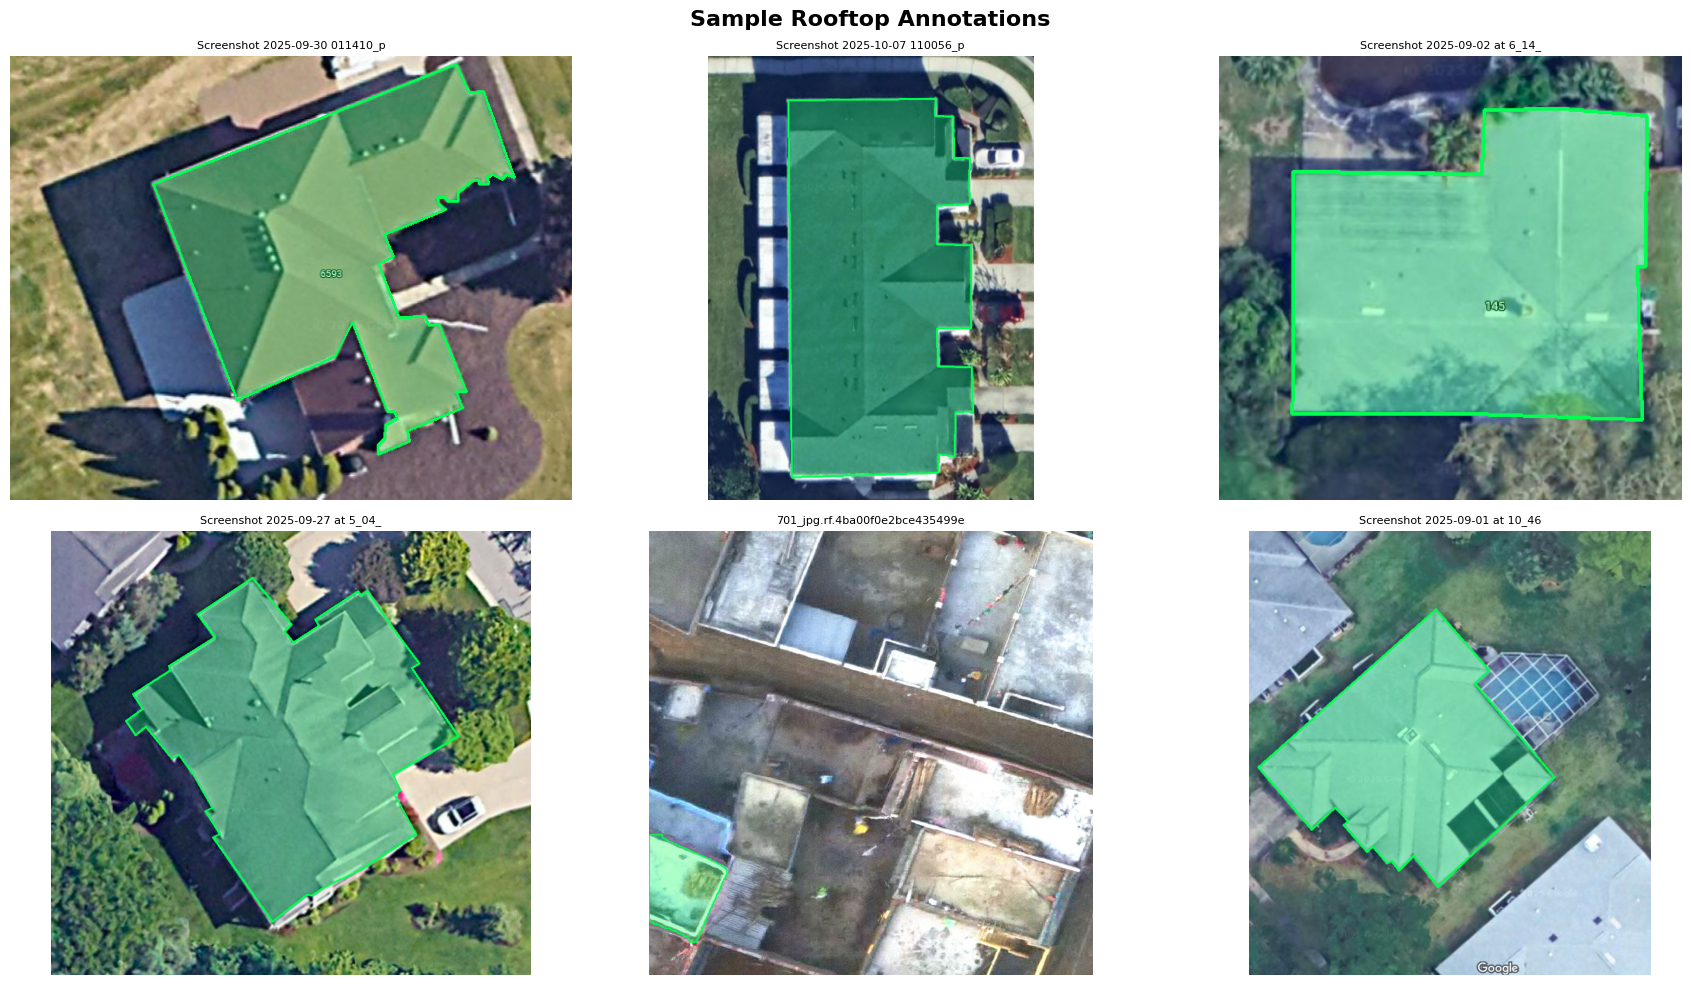

In [7]:
# ── Cell 5: Visualise Sample Annotated Images ────────────────────────────
def draw_polygon_labels(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split('\n'):
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            coords = list(map(float, parts[1:]))
            pts = np.array(
                [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords)-1, 2)],
                dtype=np.int32)
            cv2.polylines(img, [pts], True, (0, 255, 80), 2)
            overlay = img.copy()
            cv2.fillPoly(overlay, [pts], (0, 255, 80))
            img = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
    return img

_tr_imgs = list((SPLIT_DIR / 'train' / 'images').glob('*.*'))
if not _tr_imgs:
    print('No training images found. Run Cell 4 first.')
else:
    samples = random.sample(_tr_imgs, min(6, len(_tr_imgs)))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Sample Rooftop Annotations', fontsize=16, fontweight='bold')
    for ax, p in zip(axes.flat, samples):
        vis = draw_polygon_labels(p, SPLIT_DIR / 'train' / 'labels' / (p.stem + '.txt'))
        if vis is not None:
            ax.imshow(vis)
            ax.set_title(p.name[:30], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [8]:
# ── Cell 6: Auto-Annotate Unlabeled Images ───────────────────────────────
def auto_annotate_unlabeled():
    images = [p for p in UNLABELED.glob('*.*')
              if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    done = len(list(AUTO_LBL_DIR.glob('*.txt')))
    if done >= len(images):
        print(f'Already annotated: {done} files. Skipping.')
        return

    model_path = str(BEST_MODEL) if BEST_MODEL.exists() else 'yolo26m-seg.pt'
    print(f'Using model: {model_path}')
    print(f'Inference device: {DEVICE}')
    model = YOLO(model_path)

    for img_path in tqdm(images, desc='Auto-annotating'):
        lbl_out = AUTO_LBL_DIR / (img_path.stem + '.txt')
        if lbl_out.exists():
            continue
        results = model(str(img_path), verbose=False, conf=0.25, device=DEVICE)
        lines = []
        for res in results:
            if res.masks is None:
                continue
            h, w = res.orig_shape
            for mask_xy in res.masks.xy:
                coords = []
                for x, y in mask_xy:
                    coords.extend([round(float(x)/w, 6), round(float(y)/h, 6)])
                if len(mask_xy) >= 3:
                    lines.append('0 ' + ' '.join(map(str, coords)))
        lbl_out.write_text('\n'.join(lines))

    found = sum(1 for f in AUTO_LBL_DIR.glob('*.txt') if f.stat().st_size > 0)
    print(f'Annotated: {found}/{len(images)} images with detections.')

auto_annotate_unlabeled()


Already annotated: 338 files. Skipping.


In [9]:
# ── Cell 7: Merge Auto-Annotated into Training Set ───────────────────────
def merge_unlabeled_into_train():
    images = [p for p in UNLABELED.glob('*.*')
              if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    added = 0
    for img_path in images:
        lbl     = AUTO_LBL_DIR / (img_path.stem + '.txt')
        dst_img = SPLIT_DIR / 'train' / 'images' / img_path.name
        dst_lbl = SPLIT_DIR / 'train' / 'labels' / (img_path.stem + '.txt')
        if not dst_img.exists() and lbl.exists() and lbl.stat().st_size > 0:
            shutil.copy2(img_path, dst_img)
            shutil.copy2(lbl, dst_lbl)
            added += 1
    total = len(list((SPLIT_DIR / 'train' / 'images').glob('*.*')))
    print(f'Added {added} images. Total training images: {total}')

merge_unlabeled_into_train()


Added 0 images. Total training images: 1452


In [ ]:
# ── Cell 8: Train YOLOv12m-seg ───────────────────────────────────────────
import torch

MODEL_NAME = 'yolo26m-seg.pt'
EPOCHS     = 100
IMGSZ      = 640
BATCH      = COLAB_BATCH   # 16 on Colab T4, 8 local (set in Cell 1)

# DEVICE is already set in Cell 1 (GPU = 0, or 'mps', or 'cpu')
print(f'Device : {DEVICE}  |  Batch : {BATCH}  |  Model : {MODEL_NAME}')
if DEVICE == 0:
    print(f'  → Training on GPU: {torch.cuda.get_device_name(0)}')
elif DEVICE == 'cpu':
    print('  ⚠ WARNING: Training on CPU — this will be very slow!')

def train_model():
    if CHECKPOINT.exists():
        print(f'Resuming from checkpoint: {CHECKPOINT}')
        model = YOLO(str(CHECKPOINT))
        return model.train(
            resume=True, device=DEVICE,
            project=str(RUNS_DIR), name='rooftop_seg', exist_ok=True)
    print('Starting fresh training...')
    model = YOLO(MODEL_NAME)
    return model.train(
        data=str(YAML_PATH),
        epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, device=DEVICE,
        project=str(RUNS_DIR), name='rooftop_seg', exist_ok=True,
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
        flipud=0.3, fliplr=0.5, mosaic=1.0, mixup=0.1,
        optimizer='AdamW', lr0=0.001, lrf=0.01,
        warmup_epochs=3, save_period=5, patience=20,
        verbose=True, plots=True)

train_results = train_model()
print(f'Training complete! Best model: {BEST_MODEL}')


Device : 0  |  Batch : 8  |  Model : yolo26m-seg.pt
  → Training on GPU: NVIDIA GeForce RTX 2050
Starting fresh training...
Ultralytics 8.4.46  Python-3.12.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\vedan\OneDrive\Pictures\Documents\AI FOR BHARAT\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=

In [ ]:
# ── Cell 9: Plot Training Metrics ────────────────────────────────────────
_csv = RUNS_DIR / 'rooftop_seg' / 'results.csv'

if not _csv.exists():
    print('No results.csv — run Cell 8 first.')
else:
    df = pd.read_csv(_csv)
    df.columns = df.columns.str.strip()
    metrics = [
        ('train/seg_loss',       'Train Seg Loss',  'royalblue'),
        ('val/seg_loss',         'Val Seg Loss',    'tomato'),
        ('metrics/precision(M)', 'Precision',       'green'),
        ('metrics/recall(M)',    'Recall',          'orange'),
        ('metrics/mAP50(M)',     'mAP@0.5',         'purple'),
        ('metrics/mAP50-95(M)', 'mAP@0.5:0.95',   'brown'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('VAYU Training Metrics', fontsize=16, fontweight='bold')
    for ax, (col, title, color) in zip(axes.flat, metrics):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=2)
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f'{col}\nnot found', ha='center', va='center')
    plt.tight_layout()
    plt.savefig(str(BASE_DIR / 'training_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved: training_metrics.png')


In [ ]:
# ── Cell 10: Solar Calculation Engine ───────────────────────────────────
SOLAR_CONFIG = {
    'panel_area_sqm'      : 2.0,
    'panel_watt_peak'     : 400,
    'sun_hours_per_day'   : 5.5,
    'system_efficiency'   : 0.80,
    'usable_roof_fraction': 0.70,
    'cost_per_kw_inr'     : 45000,
    'electricity_rate_inr': 8.0,
    'feed_in_tariff_inr'  : 3.5,
    'annual_degradation'  : 0.005,
    'panel_life_years'    : 25,
    'co2_per_kwh_kg'      : 0.82,
    'pixels_per_meter'    : 40,
}

def estimate_inclination(mask_xy):
    pts = np.array(mask_xy, dtype=np.float32)
    if len(pts) < 3:
        return 0, 'Unknown'
    _, (bw, bh), _ = cv2.minAreaRect(pts)
    if max(bw, bh) == 0:
        return 0, 'Flat (0 deg)'
    aspect = min(bw, bh) / max(bw, bh)
    if aspect >= 0.75:   return 0,  'Flat (0 deg)'
    elif aspect >= 0.55: return 10, 'Low slope (~10 deg)'
    elif aspect >= 0.35: return 20, 'Moderate slope (~20 deg)'
    else:                return 35, 'Steep slope (~35 deg)'

def calculate_solar_metrics(mask_xy, img_shape):
    if len(mask_xy) < 3:
        return None
    c = SOLAR_CONFIG

    poly = Polygon(mask_xy)
    if not poly.is_valid:
        poly = poly.buffer(0)

    ppm           = c['pixels_per_meter']
    roof_area_sqm = poly.area / (ppm * ppm)
    usable_sqm    = roof_area_sqm * c['usable_roof_fraction']
    num_panels    = max(0, int(usable_sqm / c['panel_area_sqm']))
    system_kw     = round(num_panels * c['panel_watt_peak'] / 1000, 2)
    daily_kwh     = round(system_kw * c['sun_hours_per_day'] * c['system_efficiency'], 2)
    annual_kwh    = int(round(daily_kwh * 365))

    total_cost     = int(system_kw * c['cost_per_kw_inr'])
    annual_sav_y1  = int(annual_kwh * c['electricity_rate_inr'])

    yearly = []
    total_sav = 0.0
    for yr in range(1, c['panel_life_years'] + 1):
        s = annual_kwh * ((1 - c['annual_degradation']) ** yr) * c['electricity_rate_inr']
        yearly.append(round(s))
        total_sav += s

    net_25yr      = int(total_sav - total_cost)
    payback       = round(total_cost / annual_sav_y1, 1) if annual_sav_y1 > 0 else float('inf')
    roi           = round((net_25yr / total_cost) * 100, 1) if total_cost > 0 else 0
    co2_kg        = int(annual_kwh * c['co2_per_kwh_kg'])
    trees         = int(co2_kg / 21.77)

    incl_deg, incl_label = estimate_inclination(mask_xy)

    if num_panels >= 10 and payback <= 5:
        feas, feas_col, feas_sc = 'HIGHLY FEASIBLE',     'green',  3
    elif num_panels >= 4 and payback <= 8:
        feas, feas_col, feas_sc = 'MODERATELY FEASIBLE', 'orange', 2
    else:
        feas, feas_col, feas_sc = 'NOT RECOMMENDED',     'red',    1

    return {
        'roof_area_sqm'          : round(roof_area_sqm, 1),
        'usable_area_sqm'        : round(usable_sqm, 1),
        'num_panels'             : num_panels,
        'system_kw'              : system_kw,
        'daily_kwh'              : daily_kwh,
        'annual_kwh'             : annual_kwh,
        'total_cost_inr'         : total_cost,
        'annual_savings_inr'     : annual_sav_y1,
        'payback_years'          : payback,
        'net_profit_25yr_inr'    : net_25yr,
        'roi_percent'            : roi,
        'annual_co2_kg'          : co2_kg,
        'trees_equivalent'       : trees,
        'inclination_deg'        : incl_deg,
        'inclination_label'      : incl_label,
        'feasibility'            : feas,
        'feasibility_color'      : feas_col,
        'feasibility_score'      : feas_sc,
        'yearly_savings_breakdown': yearly,
    }

_t = calculate_solar_metrics(np.array([(0,0),(300,0),(300,300),(0,300)]), (640,640))
print('Sanity check (300x300 px square):')
for k, v in _t.items():
    if k != 'yearly_savings_breakdown':
        print(f'  {k:<28}: {v}')


In [ ]:
# ── Cell 11: Save All Annotations — JSON + 3-panel images ───────────────
def save_all_annotations():
    model_path = str(BEST_MODEL) if BEST_MODEL.exists() else 'yolo26m-seg.pt'
    print(f'Model: {model_path}')
    model = YOLO(model_path)
    ppm   = SOLAR_CONFIG['pixels_per_meter']

    all_imgs = [p for p in list(TRAIN_IMG.glob('*.*')) + list(UNLABELED.glob('*.*'))
                if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print(f'Total images: {len(all_imgs)}')
    skipped = done = 0

    for img_path in tqdm(all_imgs, desc='Annotating'):
        json_out = ANNOTATIONS_DIR / (img_path.stem + '.json')
        img_out  = ANNOTATED_IMGS_DIR / (img_path.stem + '.png')
        if json_out.exists() and img_out.exists():
            skipped += 1
            continue

        img_cv = cv2.imread(str(img_path))
        if img_cv is None:
            continue
        h, w = img_cv.shape[:2]

        res      = model(str(img_path), verbose=False, conf=0.25, device=DEVICE)[0]
        rooftops = []
        dets     = []

        if res.masks is not None:
            for idx, mask_xy in enumerate(res.masks.xy):
                if len(mask_xy) < 3:
                    continue
                m = calculate_solar_metrics(mask_xy, (h, w))
                if m is None:
                    continue
                rect = cv2.minAreaRect(mask_xy.astype(np.float32))
                rooftops.append({
                    'id':                idx + 1,
                    'polygon_pixels':    [[round(float(x),2),round(float(y),2)] for x,y in mask_xy],
                    'polygon_normalized':[[round(float(x)/w,6),round(float(y)/h,6)] for x,y in mask_xy],
                    'roof_area_sqm':     m['roof_area_sqm'],
                    'usable_area_sqm':   m['usable_area_sqm'],
                    'bbox_width_m':      round(rect[1][0]/ppm, 1),
                    'bbox_height_m':     round(rect[1][1]/ppm, 1),
                    'inclination_deg':   m['inclination_deg'],
                    'inclination_label': m['inclination_label'],
                    'solar_metrics':     {k:v for k,v in m.items() if k!='yearly_savings_breakdown'},
                    'yearly_savings_inr':m['yearly_savings_breakdown'],
                })
                dets.append((mask_xy, m))

        json_out.write_text(json.dumps({
            'image': img_path.name, 'image_width': w, 'image_height': h,
            'model_used': str(model_path),
            'total_rooftops': len(rooftops),
            'total_roof_area_sqm': round(sum(r['roof_area_sqm'] for r in rooftops), 1),
            'rooftops': rooftops,
        }, indent=2))

        if dets:
            orig, mask, annot = build_3panel(img_path, dets)
            fig, axes = plt.subplots(1, 3, figsize=(21, 7))
            for ax, panel, title in zip(axes,
                    [orig, mask, annot],
                    ['ORIGINAL', 'SEGMENTATION MASK', 'MEASUREMENTS & ANNOTATIONS']):
                ax.imshow(panel)
                ax.set_title(title, fontsize=11, fontweight='bold',
                             color='white', fontfamily='monospace')
                ax.axis('off')
            fig.patch.set_facecolor('#111111')
            for ax in axes:
                ax.set_facecolor('#111111')
            plt.tight_layout(pad=0.5)
            plt.savefig(str(img_out), dpi=110, bbox_inches='tight', facecolor='#111111')
            plt.close()

        done += 1

    print(f'Done: {done} new  |  Skipped: {skipped}')
    print(f'JSONs  : {len(list(ANNOTATIONS_DIR.glob("*.json")))}')
    print(f'Images : {len(list(ANNOTATED_IMGS_DIR.glob("*.png")))}')

save_all_annotations()


In [ ]:
# ── Cell 12: Multi-Agent Groq Debate ────────────────────────────────────
AGENT_CONFIGS = [
    {
        'name' : 'SolarOptimist',
        'model': 'llama-3.3-70b-versatile',
        'role' : ('You are an enthusiastic solar energy advocate. '
                  'Given rooftop solar metrics, highlight the strongest benefits — '
                  'energy savings, ROI, environmental impact. '
                  'Be factual and concise (3-4 sentences).'),
    },
    {
        'name' : 'RiskAnalyst',
        'model': 'llama-3.3-70b-versatile',
        'role' : ('You are a cautious financial risk analyst. '
                  'Given rooftop solar metrics, identify key risks and limitations — '
                  'payback uncertainty, roof suitability, maintenance. '
                  'Be factual and concise (3-4 sentences).'),
    },
    {
        'name' : 'Consensus',
        'model': 'llama-3.3-70b-versatile',
        'role' : ('You are an objective solar consultant. '
                  'Given an optimist view and a risk view, '
                  'synthesise a balanced final recommendation (3-4 sentences).'),
    },
]

def _call_agent(agent, prompt):
    resp = groq_client.chat.completions.create(
        model=agent['model'],
        messages=[
            {'role': 'system', 'content': agent['role']},
            {'role': 'user',   'content': prompt},
        ],
        max_tokens=256, temperature=0.7,
    )
    return resp.choices[0].message.content.strip()

def multi_agent_debate(metrics, image_name):
    summary = (
        f"Image: {image_name}\n"
        f"Roof area: {metrics['roof_area_sqm']} sqm | Usable: {metrics['usable_area_sqm']} sqm\n"
        f"Panels: {metrics['num_panels']} ({metrics['system_kw']} kW) | Annual: {metrics['annual_kwh']:,} kWh\n"
        f"Cost: Rs {metrics['total_cost_inr']:,} | Annual savings: Rs {metrics['annual_savings_inr']:,}\n"
        f"Payback: {metrics['payback_years']} yrs | 25-yr ROI: {metrics['roi_percent']}%\n"
        f"CO2 avoided: {metrics['annual_co2_kg']:,} kg/yr | Feasibility: {metrics['feasibility']}\n"
        f"Inclination: {metrics['inclination_label']}"
    )
    opt  = _call_agent(AGENT_CONFIGS[0], summary)
    risk = _call_agent(AGENT_CONFIGS[1], summary)
    cons = _call_agent(AGENT_CONFIGS[2], f"Optimist:\n{opt}\n\nRisk analyst:\n{risk}\n\nMetrics:\n{summary}")
    return {'optimist': opt, 'risk_analyst': risk, 'consensus': cons}

print('Multi-agent debate ready.')
print('Agents:', [a['name'] for a in AGENT_CONFIGS])


In [ ]:
# ── Cell 13: Full Inference Pipeline (3-panel visualisation) ────────────
import cv2, json, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Colour constants ──────────────────────────────────────────────────────
_GOLD  = (255, 178,   0)
_BLUE  = (  0, 120, 255)
_WHITE = (255, 255, 255)
_BLACK = (  0,   0,   0)

def _draw_label(img, lines, cx, cy, line_colors=None):
    font       = cv2.FONT_HERSHEY_SIMPLEX
    fscale, ft = 0.38, 1
    pad, lh    = 5, 15
    widths     = [cv2.getTextSize(l, font, fscale, ft)[0][0] for l in lines]
    bw = max(widths) + pad * 2
    bh = len(lines) * lh + pad * 2
    lx = max(0, min(cx - bw // 2, img.shape[1] - bw - 1))
    ly = max(0, min(cy - bh // 2, img.shape[0] - bh - 1))
    cv2.rectangle(img, (lx, ly), (lx + bw, ly + bh), _BLACK, -1)
    cv2.rectangle(img, (lx, ly), (lx + bw, ly + bh), _GOLD,   1)
    for j, line in enumerate(lines):
        col = line_colors[j] if line_colors and j < len(line_colors) else _WHITE
        ty  = ly + pad + (j + 1) * lh
        cv2.putText(img, line, (lx + pad, ty), font, fscale, col, ft, cv2.LINE_AA)

def build_3panel(img_path, detections):
    img_cv  = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]
    ppm     = SOLAR_CONFIG['pixels_per_meter']

    mask_panel = np.zeros((h, w, 3), dtype=np.uint8)
    annot      = (img_rgb * 0.55).astype(np.uint8)

    for idx, (mask_xy, m) in enumerate(detections):
        pts = np.array(mask_xy, dtype=np.int32)
        cv2.fillPoly(mask_panel, [pts], _GOLD)

        ov = annot.copy()
        cv2.fillPoly(ov, [pts], _GOLD)
        annot = cv2.addWeighted(annot, 0.45, ov, 0.55, 0)
        cv2.polylines(annot, [pts], True, _GOLD, 2)

        rect  = cv2.minAreaRect(pts.astype(np.float32))
        box   = cv2.boxPoints(rect).astype(np.int32)
        rw_m  = round(rect[1][0] / ppm, 1)
        rh_m  = round(rect[1][1] / ppm, 1)
        cv2.drawContours(annot, [box], 0, _BLUE, 2)

        cx     = int(np.mean(pts[:, 0]))
        cy     = int(np.mean(pts[:, 1]))
        lines  = [f'Roof #{idx+1}',
                  f'Area: {m["roof_area_sqm"]} m2',
                  f'{rw_m}m x {rh_m}m']
        colors = [_GOLD, _WHITE, (180, 220, 180)]
        if m.get('inclination_deg', 0) > 0:
            lines.append(f'Incl: {m["inclination_label"]}')
            colors.append((255, 220, 100))
        _draw_label(annot, lines, cx, cy, colors)

    return img_rgb, mask_panel, annot

def save_3panel(img_path, orig, mask, annot):
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    for ax, panel, title in zip(axes,
            [orig, mask, annot],
            ['ORIGINAL', 'SEGMENTATION MASK', 'MEASUREMENTS & ANNOTATIONS']):
        ax.imshow(panel)
        ax.set_title(title, fontsize=13, fontweight='bold',
                     color='white', fontfamily='monospace')
        ax.axis('off')
    fig.patch.set_facecolor('#111111')
    for ax in axes:
        ax.set_facecolor('#111111')
    plt.tight_layout(pad=0.5)
    out = ANNOTATED_IMGS_DIR / (Path(img_path).stem + '.png')
    plt.savefig(str(out), dpi=130, bbox_inches='tight', facecolor='#111111')
    plt.show()
    print(f'Image saved : {out}')
    return out

def analyse_rooftop_image(img_path, model=None, run_debate=True):
    img_path  = Path(img_path)
    json_path = ANNOTATIONS_DIR / (img_path.stem + '.json')

    if model is None:
        model = YOLO(str(BEST_MODEL) if BEST_MODEL.exists() else 'yolo26m-seg.pt')

    img_cv = cv2.imread(str(img_path))
    if img_cv is None:
        print(f'Cannot read: {img_path}')
        return []
    h, w = img_cv.shape[:2]
    ppm  = SOLAR_CONFIG['pixels_per_meter']

    detections  = []
    all_metrics = []

    if json_path.exists():
        ann    = json.loads(json_path.read_text())
        source = 'saved JSON'
        for roof in ann['rooftops']:
            mask_xy = np.array(roof['polygon_pixels'], dtype=np.float32)
            m       = dict(roof['solar_metrics'])
            m['yearly_savings_breakdown'] = roof.get('yearly_savings_inr', [])
            detections.append((mask_xy, m))
            all_metrics.append(m)
    else:
        res    = model(str(img_path), verbose=False, conf=0.25, device=DEVICE)[0]
        source = 'live inference'
        if res.masks is not None:
            for mask_xy in res.masks.xy:
                m = calculate_solar_metrics(mask_xy, (h, w))
                if m:
                    detections.append((mask_xy, m))
                    all_metrics.append(m)
        rooftops_json = []
        for i, (mxy, m) in enumerate(detections):
            rect = cv2.minAreaRect(np.array(mxy, dtype=np.float32))
            rooftops_json.append({
                'id': i+1,
                'polygon_pixels':     [[round(float(x),2),round(float(y),2)] for x,y in mxy],
                'polygon_normalized': [[round(float(x)/w,6),round(float(y)/h,6)] for x,y in mxy],
                'roof_area_sqm':      m['roof_area_sqm'],
                'usable_area_sqm':    m['usable_area_sqm'],
                'bbox_width_m':       round(rect[1][0]/ppm, 1),
                'bbox_height_m':      round(rect[1][1]/ppm, 1),
                'inclination_deg':    m['inclination_deg'],
                'inclination_label':  m['inclination_label'],
                'solar_metrics':      {k:v for k,v in m.items() if k!='yearly_savings_breakdown'},
                'yearly_savings_inr': m['yearly_savings_breakdown'],
            })
        json_path.write_text(json.dumps({
            'image': img_path.name, 'image_width': w, 'image_height': h,
            'model_used': str(BEST_MODEL) if BEST_MODEL.exists() else 'yolo26m-seg.pt',
            'total_rooftops': len(rooftops_json),
            'total_roof_area_sqm': round(sum(r['roof_area_sqm'] for r in rooftops_json), 1),
            'rooftops': rooftops_json,
        }, indent=2))
        print(f'JSON saved  : {json_path}')

    orig, mask, annot = build_3panel(img_path, detections)
    save_3panel(img_path, orig, mask, annot)

    sep = '=' * 62
    print(f'\nSource: {source}  |  Rooftops: {len(all_metrics)}')
    for i, m in enumerate(all_metrics):
        print(f'\n{sep}\n  ROOF #{i+1}\n{sep}')
        print(f'  Roof area          : {m["roof_area_sqm"]} m2')
        print(f'  Usable area (70%)  : {m["usable_area_sqm"]} m2')
        print(f'  Inclination (est.) : {m.get("inclination_label","N/A")}')
        print(f'  Panels             : {m["num_panels"]} x 400W = {m["system_kw"]} kW')
        print(f'  Daily generation   : {m["daily_kwh"]} kWh')
        print(f'  Annual generation  : {m["annual_kwh"]:,} kWh')
        print(f'  Installation cost  : Rs {m["total_cost_inr"]:,}')
        print(f'  Annual savings     : Rs {m["annual_savings_inr"]:,}')
        print(f'  Payback period     : {m["payback_years"]} years')
        print(f'  25-yr net profit   : Rs {m["net_profit_25yr_inr"]:,}')
        print(f'  25-yr ROI          : {m["roi_percent"]}%')
        print(f'  CO2 avoided/year   : {m["annual_co2_kg"]:,} kg')
        print(f'  Trees equivalent   : {m["trees_equivalent"]:,} trees/yr')
        print(f'  FEASIBILITY        : {m["feasibility"]}')

        savings = m.get('yearly_savings_breakdown', [])
        if savings:
            yrs   = list(range(1, len(savings)+1))
            cumul = [sum(savings[:j+1]) for j in range(len(savings))]
            plt.figure(figsize=(12, 4))
            plt.bar(yrs, savings, color='steelblue', alpha=0.7, label='Annual savings (Rs)')
            plt.plot(yrs, cumul, 'r-o', markersize=3, linewidth=2, label='Cumulative (Rs)')
            plt.axhline(m['total_cost_inr'], color='orange', linestyle='--', linewidth=2,
                        label=f'Cost Rs {m["total_cost_inr"]:,}')
            plt.xlabel('Year'); plt.ylabel('INR (Rs)')
            plt.title(f'Roof #{i+1} — 25-Year Savings')
            plt.legend(); plt.grid(True, alpha=0.3)
            plt.tight_layout(); plt.show()

    if run_debate and all_metrics:
        best = max(all_metrics, key=lambda x: x['roof_area_sqm'])
        print(f'\n{sep}\n  MULTI-AGENT DEBATE  (Groq Llama 3.3 70B)\n{sep}')
        d = multi_agent_debate(best, img_path.name)
        print(f'\n[SolarOptimist]\n{d["optimist"]}')
        print(f'\n[RiskAnalyst]\n{d["risk_analyst"]}')
        print(f'\n[CONSENSUS]\n{d["consensus"]}')

    return all_metrics

_demo = random.choice(list((SPLIT_DIR / 'val' / 'images').glob('*.*')))
print(f'Demo: {_demo.name}\n')
analyse_rooftop_image(_demo)


In [ ]:
# ── Cell 14: Batch Inference on Validation Set ───────────────────────────
def batch_analyse(image_dir, max_images=20):
    model = YOLO(str(BEST_MODEL) if BEST_MODEL.exists() else 'yolo26m-seg.pt')
    imgs  = [p for p in Path(image_dir).glob('*.*')
             if p.suffix.lower() in ('.jpg','.jpeg','.png')][:max_images]
    rows  = []
    for img_path in tqdm(imgs, desc='Batch'):
        res = model(str(img_path), verbose=False, conf=0.25, device=DEVICE)[0]
        if res.masks is None:
            continue
        for mask_xy in res.masks.xy:
            m = calculate_solar_metrics(mask_xy, res.orig_shape)
            if m:
                rows.append({'image': img_path.name,
                             **{k: m[k] for k in ['roof_area_sqm','num_panels','system_kw',
                                                   'annual_kwh','total_cost_inr','annual_savings_inr',
                                                   'payback_years','roi_percent','feasibility',
                                                   'inclination_deg','inclination_label']}})
    if not rows:
        print('No rooftops detected.')
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    csv_path = BASE_DIR / 'batch_solar_analysis.csv'
    df.to_csv(csv_path, index=False)
    print(f'Saved: {csv_path}')
    print(df[['roof_area_sqm','num_panels','annual_kwh',
              'total_cost_inr','payback_years','roi_percent']].describe().round(1))

    cmap = {'HIGHLY FEASIBLE':'green','MODERATELY FEASIBLE':'orange','NOT RECOMMENDED':'red'}
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Batch Analysis Summary', fontsize=14, fontweight='bold')
    fc = df['feasibility'].value_counts()
    axes[0].bar(fc.index, fc.values, color=[cmap.get(f,'gray') for f in fc.index])
    axes[0].set_title('Feasibility'); axes[0].tick_params(axis='x', rotation=15)
    axes[1].hist(df['num_panels'], bins=15, color='steelblue', edgecolor='white')
    axes[1].set_title('Panels Per Roof'); axes[1].set_xlabel('Panels')
    axes[2].hist(df['payback_years'].clip(0,15), bins=15, color='orange', edgecolor='white')
    axes[2].set_title('Payback Period'); axes[2].set_xlabel('Years')
    plt.tight_layout(); plt.show()
    return df

summary_df = batch_analyse(SPLIT_DIR / 'val' / 'images', max_images=20)


In [ ]:
# ── Cell 15: Analyse Your Own Image ─────────────────────────────────────
# Change _filename to any image in the all/ folder,
# or override MY_IMAGE_PATH with a full path.

_filename     = '1026_jpg.rf.6aa70e326685bba6f16eb4c8aca15c28.jpg'
MY_IMAGE_PATH = str(BASE_DIR / 'all' / _filename)

# Full-path overrides:
# MY_IMAGE_PATH = '/content/drive/MyDrive/AI_for_Bharat/all/my_image.jpg'  # Colab
# MY_IMAGE_PATH = r'C:\path\to\your\image.jpg'                          # Local Windows

if Path(MY_IMAGE_PATH).exists():
    analyse_rooftop_image(MY_IMAGE_PATH, run_debate=True)
else:
    print(f'File not found: {MY_IMAGE_PATH}')
    print('Edit _filename above or set MY_IMAGE_PATH to a full path.')


In [ ]:
# ── Cell 16: Model Evaluation ────────────────────────────────────────────
import torch as _torch

if not BEST_MODEL.exists():
    print('No trained model. Run Cell 8 first.')
else:
    # DEVICE is already set in Cell 1 (GPU = 0, or 'mps', or 'cpu')
    _imgsz = 640
    _batch = COLAB_BATCH
    print(f'Evaluating on device: {DEVICE}')
    model = YOLO(str(BEST_MODEL))
    vr = model.val(data=str(YAML_PATH), imgsz=_imgsz, batch=_batch, device=DEVICE, verbose=True)
    print(f'\nValidation Results:')
    print(f'  mAP@0.5      (mask): {vr.seg.map50:.4f}')
    print(f'  mAP@0.5:0.95 (mask): {vr.seg.map:.4f}')
    print(f'  Precision    (mask): {vr.seg.mp:.4f}')
    print(f'  Recall       (mask): {vr.seg.mr:.4f}')


In [ ]:
# ── Cell 17: Summary Dashboard ───────────────────────────────────────────
sep = '=' * 65
print(sep)
print('  VAYU ROOFTOP SOLAR PIPELINE — STATUS')
print(sep)
print(f'  Train images          : {len(list(TRAIN_IMG.glob("*.*"))):,}')
print(f'  Unlabeled (all/)      : {len(list(UNLABELED.glob("*.*"))):,}')
print(f'  Auto-annotated labels : {len(list(AUTO_LBL_DIR.glob("*.txt"))):,}')
print(f'  Final train set       : {len(list((SPLIT_DIR/"train"/"images").glob("*.*"))):,}')
print(f'  Validation set        : {len(list((SPLIT_DIR/"val"/"images").glob("*.*"))):,}')
print(f'  Saved JSON annotations: {len(list(ANNOTATIONS_DIR.glob("*.json"))):,}')
print(f'  Annotated images saved: {len(list(ANNOTATED_IMGS_DIR.glob("*.*"))):,}')
print(f'  Best model exists     : {BEST_MODEL.exists()}')
print(f'  Checkpoint exists     : {CHECKPOINT.exists()}')
print()
print('  Solar Config (Karnataka):')
print(f'    Panel      : {SOLAR_CONFIG["panel_area_sqm"]} sqm | {SOLAR_CONFIG["panel_watt_peak"]}W')
print(f'    Sun hours  : {SOLAR_CONFIG["sun_hours_per_day"]}h/day')
print(f'    Efficiency : {int(SOLAR_CONFIG["system_efficiency"]*100)}%')
print(f'    Cost/kW    : Rs {SOLAR_CONFIG["cost_per_kw_inr"]:,}')
print(f'    Rate       : Rs {SOLAR_CONFIG["electricity_rate_inr"]}/kWh')
print()
print('  Multi-Agent Debate:')
for a in AGENT_CONFIGS:
    print(f'    {a["name"]:<20} -> {a["model"]}')
print()
print('  Output directories:')
print(f'    Models     : {RUNS_DIR}')
print(f'    Annotations: {ANNOTATIONS_DIR}')
print(f'    Images     : {ANNOTATED_IMGS_DIR}')
print(sep)
